In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_excel("/content/OnlineRetail.xlsx")

print(df.head())
print(df.info())
print(df.isnull().sum())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-01-12 08:26:00       2.55     17850.0  United Kingdom  
1  2010-01-12 08:26:00       3.39     17850.0  United Kingdom  
2  2010-01-12 08:26:00       2.75     17850.0  United Kingdom  
3  2010-01-12 08:26:00       3.39     17850.0  United Kingdom  
4  2010-01-12 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       ------------

In [5]:
df.dropna(subset=['CustomerID'], inplace=True)

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [6]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [7]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

recency = df.groupby('CustomerID')['InvoiceDate'].max()

recency = (snapshot_date - recency).dt.days

In [8]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [9]:
monetary = df.groupby('CustomerID')['TotalAmount'].sum()

In [10]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,327,1,77183.60
12347.0,41,7,4310.00
12348.0,77,4,1797.24
12349.0,20,1,1757.55
12350.0,312,1,334.40


In [11]:
print(rfm.describe())

print("Average Purchase Value:",
      rfm['Monetary'].mean())

print("Average Purchase Frequency:",
      rfm['Frequency'].mean())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean    106.470954     4.272015    2054.266460
std     115.082161     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      23.000000     1.000000     307.415000
50%      62.000000     2.000000     674.485000
75%     162.750000     5.000000    1661.740000
max     698.000000   209.000000  280206.020000
Average Purchase Value: 2054.2664601198708
Average Purchase Frequency: 4.272014753342554


In [12]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

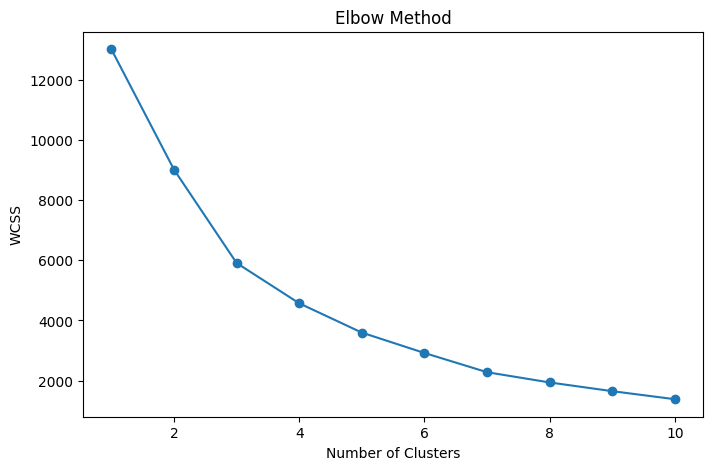

In [13]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,327,1,77183.60,3
12347.0,41,7,4310.00,1
12348.0,77,4,1797.24,1
12349.0,20,1,1757.55,1
12350.0,312,1,334.40,0


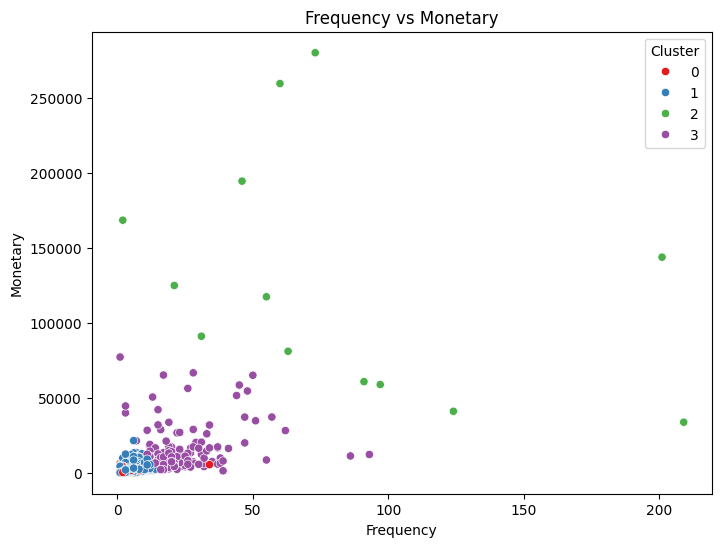

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Frequency vs Monetary")
plt.show()

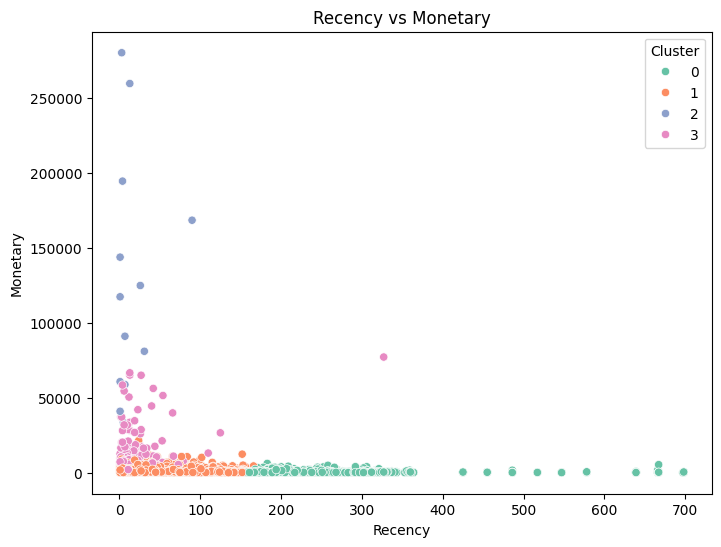

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Recency vs Monetary")
plt.show()

In [17]:
cluster_profile = rfm.groupby('Cluster').mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0        268.468891   1.550947     498.863509
1         53.227575   3.712625    1362.709370
2         14.615385  82.538462  127338.313846
3         18.126214  22.155340   12626.286359


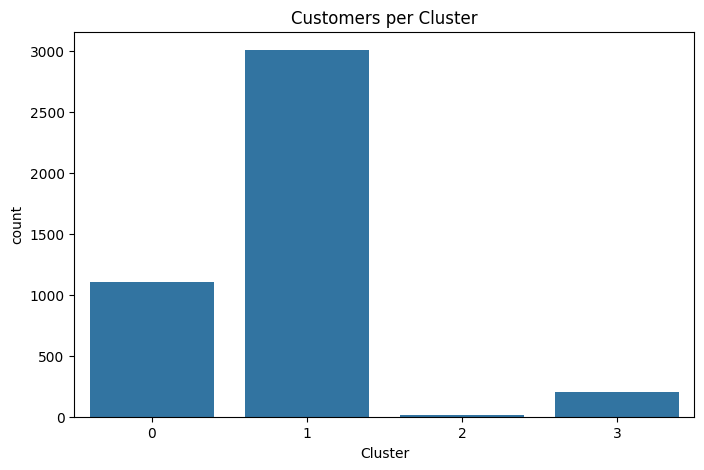

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=rfm
)

plt.title("Customers per Cluster")
plt.show()